The following line is useful when running PySPEDAS notebooks in Google Colab, to ensure that the pyspedas package is installed in the environment.
    
    
You can comment this out, or skip this cell if you're running the notebook in an environment that already includes PySPEDAS.

In [1]:
!pip install pyspedas

## Example 1: Minimal PySPEDAS example

This example loads some THEMIS magnetometer data and plots it.

Import the PySPEDAS routines we'll be using

In [2]:
import pyspedas
from pyspedas.projects.themis import fgm
from pyspedas import tplot

Now call the THEMIS fgm() routine to load some data.

In [3]:
fgm_vars = fgm(trange=['2007-03-23','2007-03-24'],probe='a',level='l2')

17-Dec-25 21:16:07: Downloading remote index: https://themis.ssl.berkeley.edu/data/themis/tha/l2/fgm/2007/
17-Dec-25 21:16:09: File is current: themis_data/tha/l2/fgm/2007/tha_l2_fgm_20070323_v01.cdf


Now print fgm_vars to see what was loaded.

In [4]:
print(fgm_vars)

['tha_fgs_btotal', 'tha_fgs_gse', 'tha_fgs_gsm', 'tha_fgs_dsl', 'tha_fgl_btotal', 'tha_fgl_gse', 'tha_fgl_gsm', 'tha_fgl_dsl', 'tha_fgl_ssl', 'tha_fgh_btotal', 'tha_fgh_gse', 'tha_fgh_gsm', 'tha_fgh_dsl', 'tha_fgh_ssl', 'tha_fge_btotal', 'tha_fge_gse', 'tha_fge_gsm', 'tha_fge_dsl', 'tha_fge_ssl']


Now plot some data.  We'll choose the FGS (spin fit) and FGL (fast survey) data in GSE coordinates.  

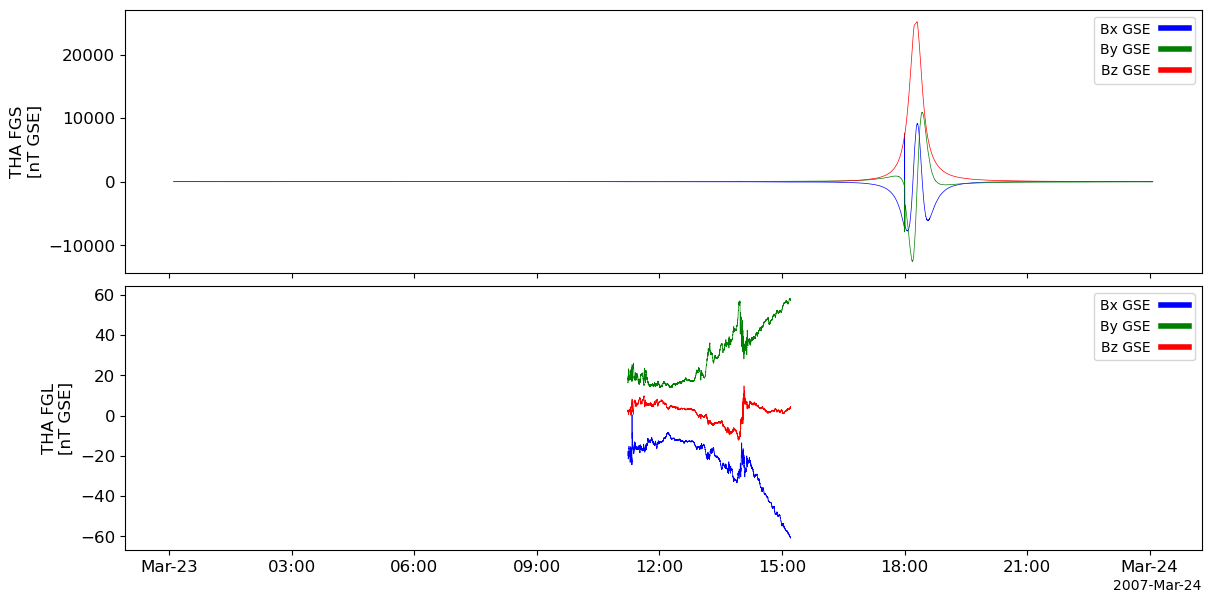

In [5]:
tplot(['tha_fgs_gse', 'tha_fgl_gse'])

## Example 2: Examining tplot variables

The get_data routine can be used to get the Python time and data arrays, or the metadata and plot options, from a tplot variable.
Let's import get_data and use it on one of the tplot variables we just plotted.

In [6]:
from pyspedas import get_data

# get_data returns a tuple of named fields containing times, data values, and possible other arrays (v, v2, v3) with bin values for multidimensional data arrays.

fgs_vals = get_data('tha_fgs_gse')

# Print the first few timestamps and data values

# The timestamp array is in fgs_vals.times, and the data array is in fgs_vals.y.

print(fgs_vals.times[0:3])

# We know that the data values are going to be a 2-d array storing 3-vectors at each timestamp

print(fgs_vals.y[0:3,:])


[1.1746084e+09 1.1746084e+09 1.1746084e+09]
[[16.226826  -9.253446  14.0618105]
 [16.214455  -9.2751665 14.08444  ]
 [16.255419  -9.394993  14.079736 ]]


The timestamps are returned as floating-point Unix times.   The time_string routine can be used for more human-friendly output.

In [7]:
from pyspedas import time_string

print(time_string(fgs_vals.times[0:3]))

['2007-03-23 00:06:38.175756', '2007-03-23 00:06:41.267882', '2007-03-23 00:06:44.360008']


We can make another call to get_data to get the metadata, which may include units, coordinate systems, and plot options.  
To get the metadata instead of the data values, use metadata=True in the get_data call.

In [8]:
fgs_md = get_data('tha_fgs_gse', metadata=True)

# This returns a dictionary of metadata from the original CDF, plus additional attributes added by PySPEDAS.
# The units and coordinate system are stored in the 'data_att' entry.

print(fgs_md['data_att'])

{'coord_sys': 'GSE', 'units': 'nT GSE', 'depend_1_units': 'nT GSE', 'depend_2_units': None, 'depend_3_units': None}


We'll show some of the plot options here, just as an example, but it's better to use pyspedas.options() to set them,
rather than manipulating them directly in the metadata dictionary.  

In [9]:
print(fgs_md['plot_options']['yaxis_opt'])


{'axis_label': 'THA FGS', 'crosshair': 'Y', 'y_axis_type': 'linear', 'y_range': [np.float32(-12535.531), np.float32(25173.793)], 'axis_subtitle': '[nT GSE]', 'legend_names': ['Bx GSE', 'By GSE', 'Bz GSE']}


## Example 3: Creating new tplot variables

The way to create new tplot variables is with the 'store_data' routine.   We'll import it, create a new data array, and store it in a new tplot variable.

In [10]:
# We need to import store_data

from pyspedas import store_data

# We'll create a new data array by scaling the original array

scaled_yvals = fgs_vals.y / 50.0

# We'll re-use the time array and metadata dictionary.   store_data takes a dictionary with entries 'x' (for times), 'y' (for data values), 
# and optional additional entries for arrays v, v2, etc. in the case of multidimentsional arrays.

# The metadata is specified via the 'attr_dict' keyword.

store_data('rescaled_data',{'x':fgs_vals.times, 'y': scaled_yvals}, attr_dict=fgs_md)

True

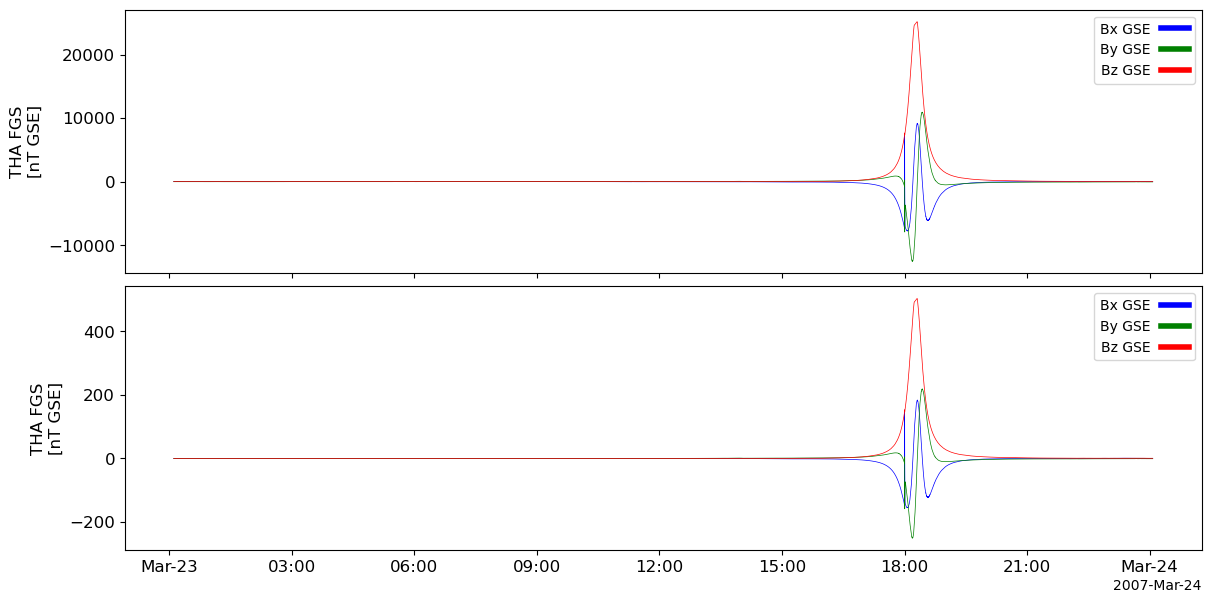

In [11]:
# Now let's plot the original and scaled tplot variables

tplot(['tha_fgs_gse','rescaled_data'])


## Example 4: Listing available tplot variables with tnames() and tplot_names()

It's not always clear what tplot variables will be created by a given set of PySPEDAS calls.   The tnames() and tplot_names() routines 
are useful, especially in interactive sessions, to see what tplot variables are currently loaded.

tnames() returns a list, while tplot_names() prints a list.

tnames can also take an input pattern, which can be used as a wildcard expression or regular expression to return variable names matchine
the input pattern.  

In [17]:
from pyspedas import tnames, tplot_names

# Print all variables

print("Calling tplot_names()")
tplot_names()

# Return a list of names for further processing (no output produced until we explicitly print it)

print("Calling tnames()")
all_tvars = tnames()
print("First 3 variables returned: ", all_tvars[0:3])

# Use a wildcard pattern with tnames() to find tplot variable names ending with "gse"
print("Calling tnames('*gse')")
gse_list = tnames('*gse')
print("gse_list:")
print(gse_list)




Calling tplot_names()
0 : tha_fgs_btotal
1 : tha_fgs_gse
2 : tha_fgs_gsm
3 : tha_fgs_dsl
4 : tha_fgl_btotal
5 : tha_fgl_gse
6 : tha_fgl_gsm
7 : tha_fgl_dsl
8 : tha_fgl_ssl
9 : tha_fgh_btotal
10 : tha_fgh_gse
11 : tha_fgh_gsm
12 : tha_fgh_dsl
13 : tha_fgh_ssl
14 : tha_fge_btotal
15 : tha_fge_gse
16 : tha_fge_gsm
17 : tha_fge_dsl
18 : tha_fge_ssl
19 : rescaled_data
Calling tnames()
First 3 variables returned:  ['tha_fgs_btotal', 'tha_fgs_gse', 'tha_fgs_gsm']
Calling tnames('*gse')
gse_list:
['tha_fgs_gse', 'tha_fgl_gse', 'tha_fgh_gse', 'tha_fge_gse']
